In [1]:
# clone repo

import os

PROJECT_ROOT = "/content/Project_Generative_AI_for_Data_Augmentation"

if not os.path.exists(PROJECT_ROOT):
    !git clone https://github.com/Jorj91/Project_Generative_AI_for_Data_Augmentation.git {PROJECT_ROOT}

%cd {PROJECT_ROOT}

Cloning into '/content/Project_Generative_AI_for_Data_Augmentation'...
remote: Enumerating objects: 115, done.
remote: Counting objects: 100% (115/115), done.
remote: Compressing objects: 100% (105/105), done.
remote: Total 115 (delta 53), reused 42 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (115/115), 6.91 MiB | 20.05 MiB/s, done.
Resolving deltas: 100% (53/53), done.
/content/Project_Generative_AI_for_Data_Augmentation


In [2]:
# Setup

import torch
import logging
from torchvision.datasets import OxfordIIITPet
import numpy as np


PROJECT_ROOT = os.getcwd()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)

In [4]:
PROJECT_ROOT # it has to be /content/Project_Generative_AI_for_Data_Augmentation

'/content/Project_Generative_AI_for_Data_Augmentation'

In [5]:
# Dependency install
INSTALL_DEPS = True

if INSTALL_DEPS:
    !pip install -r requirements.txt -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 45.0 MB/s eta 0:00:00


In [6]:
# control flags
RUN_CAPTIONING = True
RUN_TEXT_VARIATION = True
RUN_IMAGE_GENERATION = False
RUN_TRAINING = False

In [7]:
# dataset loading

dataset_train = OxfordIIITPet(
    root=os.path.join(PROJECT_ROOT, "data", "raw"),
    split="trainval",
    download=True
)

dataset_test = OxfordIIITPet(
    root=os.path.join(PROJECT_ROOT, "data", "raw"),
    split="test",
    download=True
)

print("Train size:", len(dataset_train))
print("Test size:", len(dataset_test))

100%|██████████| 792M/792M [00:45<00:00, 17.4MB/s]
100%|██████████| 19.2M/19.2M [00:02<00:00, 9.25MB/s]


Train size: 3680
Test size: 3669


In [8]:
# load split

split_path = os.path.join(PROJECT_ROOT, "data", "splits", "train_small_indices.npy")

if os.path.exists(split_path):
    train_small_idx = np.load(split_path)
    print("Loaded 30% split:", len(train_small_idx))
else:
    print("Split not found. Run captioning notebook first.")

Loaded 30% split: 1104


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

BLIP-2 loaded successfully


100%|██████████| 1104/1104 [13:16<00:00,  1.39it/s]


Full caption generation completed.


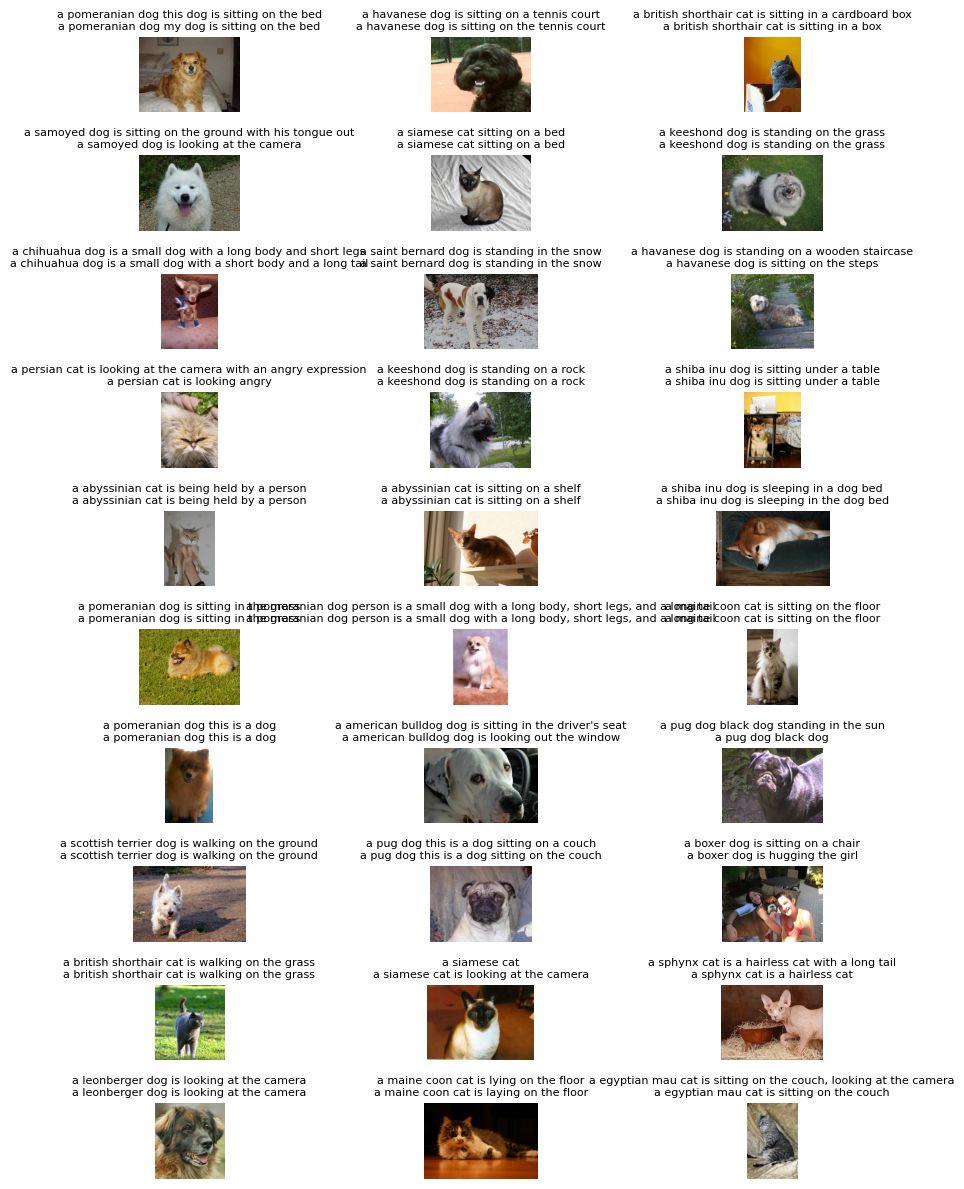

In [9]:
# integrate 01_captioning (it takes 15 minutes to execute with A100 GPU on Colab)
if RUN_CAPTIONING:
    %run notebooks/01_captioning.ipynb

In [10]:
# integrate 02_text_variation
if RUN_TEXT_VARIATION:
    %run notebooks/02_text_variation.ipynb

Cloning into 'Project_Generative_AI_for_Data_Augmentation'...
remote: Enumerating objects: 115, done.
remote: Counting objects: 100% (115/115), done.
remote: Compressing objects: 100% (105/105), done.
remote: Total 115 (delta 53), reused 42 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (115/115), 6.91 MiB | 20.46 MiB/s, done.
Resolving deltas: 100% (53/53), done.
/content/Project_Generative_AI_for_Data_Augmentation/Project_Generative_AI_for_Data_Augmentation


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

...

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

Wed Feb 18 10:49:40 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   32C    P0             58W /  400W |   24726MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

100%|██████████| 10/10 [00:47<00:00,  4.73s/it]


In [2]:

# ! git config --global user.email "fellinegiorgia@gmail.com"
# ! git config --global user.name "Jorj91"

# !git remote remove origin

# !git remote add origin https://MY_TOKEN@github.com/Jorj91/Project_Generative_AI_for_Data_Augmentation.git

# ! git push --set-upstream origin main

# ! git add .

# ! git commit -m "add library in requirements"

# ! git push


Branch 'main' set up to track remote branch 'main' from 'origin'.
Everything up-to-date
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
Everything up-to-date
